# Resume Classification Pipeline
This notebook performs preprocessing and classification on a resume dataset.

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import fitz

In [14]:
# Load the dataset
df = pd.read_csv("filtered_data.csv")
df.head()


,Unnamed: 0,Category,Resume,Resume_length,Normalized_Resume,Tokenized_Lemmatized_Resume,Extracted_Features,Cluster_Labels
0,0,Data Science,Skills * Programming Languages: Python (pandas...,4786,Skills Programming Languages Python pandas num...,"['Skills', 'Programming', 'Languages', 'Python...","['Languages', 'Python', 'Sql', 'Java', 'JavaSc...",7
1,1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,1268,Education Details May to May BE UITRGPV Data S...,"['Education', 'Details', 'May', 'to', 'May', '...","['May', 'May', 'BE', 'UITRGPV', 'Data', 'Scien...",0
2,2,Data Science,"Areas of Interest Deep Learning, Control Syste...",1871,Areas of Interest Deep Learning Control System...,"['Areas', 'of', 'Interest', 'Deep', 'Learning'...","['Interest', 'Deep', 'Learning', 'Control', 'S...",0
3,3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,6995,Skills R Python SAP HANA Tableau SAP HANA SQL ...,"['Skills', 'R', 'Python', 'SAP', 'HANA', 'Tabl...","['Skills', 'R', 'Python', 'SAP', 'HANA', 'Tabl...",3
4,4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",452,Education Details MCA YMCAUST Faridabad Haryan...,"['Education', 'Details', 'MCA', 'YMCAUST', 'Fa...","['Details', 'MCA', 'YMCAUST', 'Faridabad', 'Ha...",0


In [15]:
# Encode target labels
le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])
labels = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", labels)


Label Mapping: {'Advocate': 0, 'Arts': 1, 'Automation Testing': 2, 'Blockchain': 3, 'Business Analyst': 4, 'Civil Engineer': 5, 'Data Science': 6, 'Database': 7, 'DevOps Engineer': 8, 'DotNet Developer': 9, 'ETL Developer': 10, 'Electrical Engineering': 11, 'HR': 12, 'Hadoop': 13, 'Health and fitness': 14, 'Java Developer': 15, 'Mechanical Engineer': 16, 'Network Security Engineer': 17, 'Operations Manager': 18, 'PMO': 19, 'Python Developer': 20, 'SAP Developer': 21, 'Sales': 22, 'Testing': 23, 'Web Designing': 24}


In [16]:
# Vectorize using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['Normalized_Resume'])
y = df['Category_encoded']


In [17]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [18]:
# Try different models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear')
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, preds, target_names=le.classes_))



Training Naive Bayes...

Naive Bayes Classification Report:
                           precision    recall  f1-score   support

                 Advocate       0.00      0.00      0.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       1.00      0.40      0.57         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      0.50      0.67         6
           Civil Engineer       1.00      0.60      0.75         5
             Data Science       1.00      0.50      0.67         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       0.77      0.91      0.83        11
         DotNet Developer       1.00      0.20      0.33         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9


c:\Users\2022k\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\2022k\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\2022k\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo


Logistic Regression Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                 

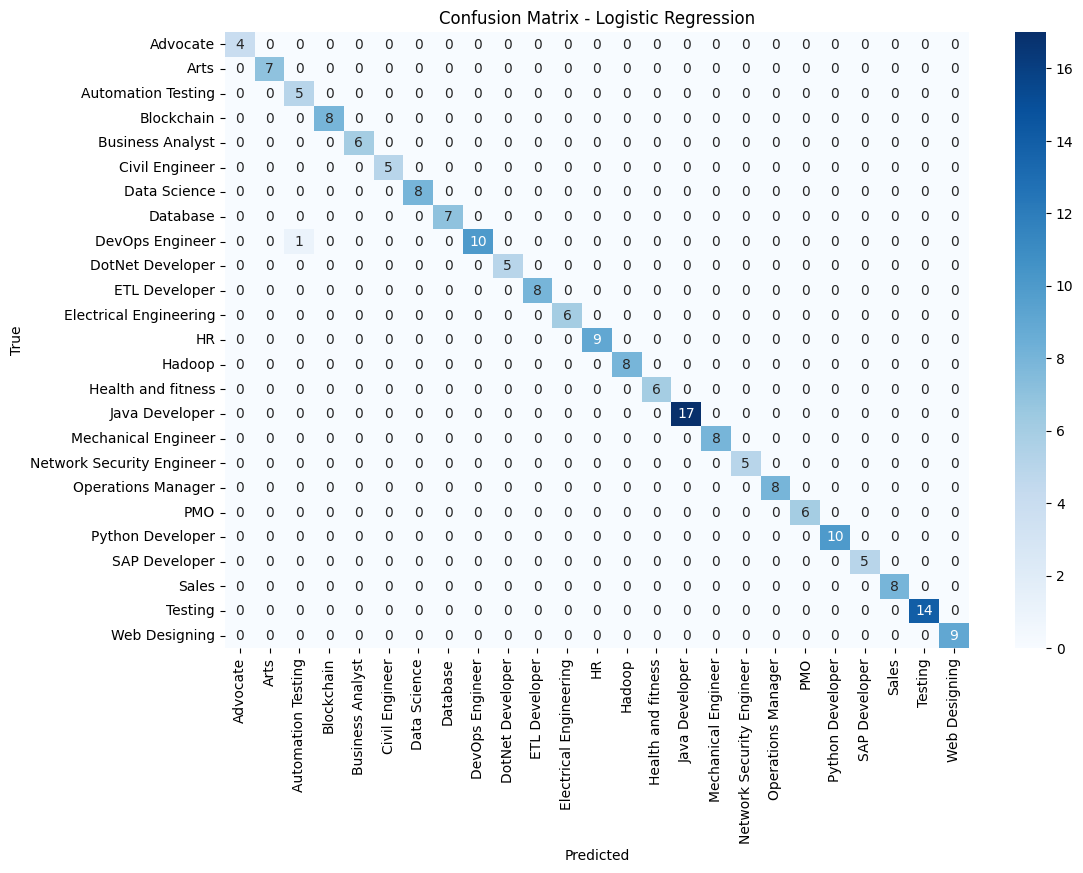

In [19]:
# Plot confusion matrix for Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
preds = model.predict(X_test)

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [20]:
from sklearn.metrics import classification_report, accuracy_score

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, preds, target_names=le.classes_))
    accuracy = accuracy_score(y_test, preds)
    print(f"Accuracy for {name}: {accuracy:.4f}")



Training Naive Bayes...

Naive Bayes Classification Report:
                           precision    recall  f1-score   support

                 Advocate       0.00      0.00      0.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       1.00      0.40      0.57         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      0.50      0.67         6
           Civil Engineer       1.00      0.60      0.75         5
             Data Science       1.00      0.50      0.67         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       0.77      0.91      0.83        11
         DotNet Developer       1.00      0.20      0.33         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9


c:\Users\2022k\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\2022k\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\2022k\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo


Logistic Regression Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                 

In [21]:
from sklearn.linear_model import LogisticRegression

# Sample resume text (you can replace this with any resume content)
sample_resume = '''
Experienced Data Scientist with a strong background in Python, Machine Learning, and Data Visualization.
Skilled in data preprocessing, model building, and deploying models using Flask and Docker.
Proficient with libraries such as Pandas, NumPy, Scikit-learn, and TensorFlow.
'''

# Vectorize the resume using the same TF-IDF vectorizer
sample_vectorized = tfidf.transform([sample_resume])

# Train (or reuse) the best model – assuming Logistic Regression for demo
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)

# Make a prediction
sample_pred = best_model.predict(sample_vectorized)

# Decode predicted label
predicted_category = le.inverse_transform(sample_pred)[0]
print(f"Predicted Category: {predicted_category}")


Predicted Category: Data Science


In [11]:
import pickle

# Train your best model again (if needed)
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)

# Save the TF-IDF vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save the trained classifier model
with open("classifier_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save the label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ All components saved")


✅ All components saved


In [22]:
# ------------------------------
# Resume Screening Functionality
# ------------------------------

from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Input a specific job description
job_description = """
We are looking for a data analyst with strong Python skills, experience in SQL, data visualization, and a good grasp of statistics.
"""

# Step 2: Normalize job description using same method used for resumes
# If you have a custom function like normalize_text(), use it here
def normalize_text(text):
    import re
    text = re.sub(r'\W+', ' ', text.lower())  # basic cleaning
    return text

job_description_cleaned = normalize_text(job_description)

# Step 3: Transform the job description using the same TF-IDF vectorizer
job_vector = tfidf.transform([job_description_cleaned])

# Step 4: Compute cosine similarity with each resume
similarities = cosine_similarity(job_vector, X).flatten()

# Step 5: Add scores to DataFrame and show top matches
df['Matching_Score'] = similarities
df_sorted = df.sort_values(by='Matching_Score', ascending=False)

# Step 6: Show top 10 matches
df_sorted[['Category', 'Matching_Score']].head(10)


,Category,Matching_Score
6,Data Science,0.389950
36,Data Science,0.389950
26,Data Science,0.389950
16,Data Science,0.389950
19,Data Science,0.270121
39,Data Science,0.270121
9,Data Science,0.270121
29,Data Science,0.270121
719,Database,0.189244
741,Database,0.189244
